# Clasificación de Preguntas Acusatorias en Contratos Públicos

Yahashua Paredes 00336691  
Machine Learning

**Objetivo:** Identificar automáticamente preguntas con contenido acusatorio en procesos de contratación pública ecuatoriana, mediante técnicas de procesamiento de lenguaje natural y machine learning sobre texto en español.

---

## Índice
1. Configuración del ambiente
2. Introducción
3. Carga y exploración de datos (EDA)
4. Preprocesamiento y Feature Extraction
5. Feature Selection
6. Pipelines con Modelos
7. Optimización de Hiperparámetros (Repeated K-Fold CV + Optuna)
8. Comparación Estadística de 2 Técnicas ML
9. Visualización con TSNE
10. Conclusiones
11. Referencias

---

---
## 1. Configuración del Ambiente

Se instalan las dependencias necesarias, se configuran los imports globales, se monta Google Drive para persistir el dataset y los outputs, y se verifica la disponibilidad de GPU. Los modelos basados en TF-IDF (LR y SVM) corren en CPU con scikit-learn; BETO utiliza la GPU T4 de Colab para inferencia y fine-tuning con PyTorch.

In [ ]:
import os
os.system('pip install -q transformers==4.40.0 accelerate optuna openpyxl imbalanced-learn')
print('Dependencias instaladas')

Dependencias instaladas


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, re, joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_val_score,
    StratifiedKFold, train_test_split, learning_curve
)
from sklearn.metrics import (
    classification_report, f1_score as sk_f1,
    precision_score, recall_score,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectPercentile, chi2
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import wilcoxon

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

CUML_AVAILABLE = False

warnings.filterwarnings('ignore')
np.random.seed(42)
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | sklearn CPU activo')

NumPy 2.0.2 | Pandas 2.2.2 | sklearn CPU activo


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH   = Path('/content/drive/MyDrive/ML_Proyecto')
DRIVE_PATH.mkdir(parents=True, exist_ok=True)
DATASET_PATH = DRIVE_PATH / 'dataset.xlsx'
OUTPUT_PATH  = DRIVE_PATH / 'outputs'
OUTPUT_PATH.mkdir(exist_ok=True)

print(f'Drive montado')
print(f'Dataset esperado en: {DATASET_PATH}')
print(f'Outputs en: {OUTPUT_PATH}')

Mounted at /content/drive
Drive montado
Dataset esperado en: /content/drive/MyDrive/ML_Proyecto/dataset.xlsx
Outputs en: /content/drive/MyDrive/ML_Proyecto/outputs


In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print('T4 disponible para BETO — LR/SVM corren en CPU (sklearn)')
else:
    print('Sin GPU — ir a Runtime -> Change runtime type -> T4 GPU')

print('\nTiempo estimado Optuna 10x10 con sklearn CPU: ~2-3 horas')
print('Puedes dejarlo correr en background.')

PyTorch device: cpu
Sin GPU — ir a Runtime -> Change runtime type -> T4 GPU

Tiempo estimado Optuna 10x10 con sklearn CPU: ~2-3 horas
Puedes dejarlo correr en background.


In [ ]:
def cv_score_gpu(make_pipeline, X, y, cv):
    """
    Wrapper de cross_val_score con sklearn puro (n_jobs=-1 usa todos los cores CPU).
    make_pipeline: callable sin argumentos que retorna un Pipeline nuevo.
    Retorna array numpy de F1-macro por fold.
    """
    pipe = make_pipeline()
    return cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)

print("cv_score_gpu definida (sklearn CPU, todos los cores)")

cv_score_gpu definida (sklearn CPU, todos los cores)


---
## 2. Introducción

En los procesos de contratación pública, los proveedores pueden realizar preguntas a las entidades contratantes durante la fase de aclaraciones. Algunas de estas preguntas tienen un carácter **acusatorio**: cuestionan directamente la legalidad, imparcialidad o coherencia técnica del proceso, lo cual puede indicar irregularidades o conflictos de interés.

La identificación manual de estas preguntas es costosa y subjetiva. Este proyecto propone automatizar dicha clasificación mediante **machine learning sobre texto en español**, comparando modelos clásicos basados en TF-IDF (Regresión Logística y SVM Lineal) con representaciones densas generadas por BETO, el modelo BERT preentrenado en español.

El principal desafío del problema es el **severo desbalance de clases**: solo ~3% de las preguntas son acusatorias, lo que requiere estrategias específicas como `class_weight="balanced"` y el uso de métricas apropiadas como F1-macro en lugar de accuracy.

---
## 3. Carga y Exploración de Datos (EDA)

Se carga el dataset desde Google Drive en un DataFrame de pandas. La columna objetivo es `final_pregunta_isAcusatoria` (binaria: 0 = no acusatoria, 1 = acusatoria) y la columna de texto es `pregunta`. Se realiza un análisis exploratorio que incluye la distribución de clases, la longitud de los textos por clase y las palabras más frecuentes en cada categoría, con el objetivo de entender la naturaleza del desbalance y las diferencias lingüísticas entre clases.

In [ ]:
df = pd.read_excel(DATASET_PATH)
TARGET   = 'final_pregunta_isAcusatoria'
TEXT_COL = 'pregunta'

print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head(3)

Shape: (5005, 5)
Columnas: ['contract_id', 'pregunta_id', 'pregunta', 'sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']


,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0


In [ ]:
print('=== Informacion general ===')
df.info()
print('\n=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Descripcion numerica ===')
df.describe()

=== Informacion general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   contract_id                  5005 non-null   int64 
 1   pregunta_id                  5005 non-null   int64 
 2   pregunta                     5005 non-null   object
 3   sum_pregunta_isAcusatoria    5005 non-null   int64 
 4   final_pregunta_isAcusatoria  5005 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 195.6+ KB

=== Valores nulos ===
contract_id                    0
pregunta_id                    0
pregunta                       0
sum_pregunta_isAcusatoria      0
final_pregunta_isAcusatoria    0
dtype: int64

=== Descripcion numerica ===


,contract_id,pregunta_id,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
count,5.005000e+03,5.005000e+03,5005.000000,5005.000000
mean,1.195276e+06,8.130700e+05,0.116284,0.029371
std,5.078579e+05,4.582516e+05,0.466359,0.168860
min,2.787000e+03,1.570200e+04,0.000000,0.000000
25%,8.493220e+05,4.249760e+05,0.000000,0.000000
50%,1.335363e+06,8.180430e+05,0.000000,0.000000
75%,1.626339e+06,1.205766e+06,0.000000,0.000000
max,1.833788e+06,1.614224e+06,3.000000,1.000000


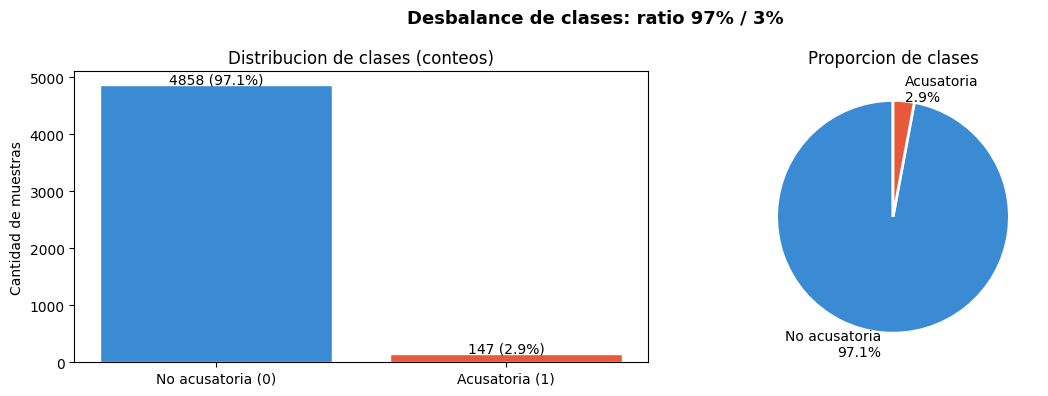

Ratio de desbalance: 33.0:1


In [ ]:
class_counts = df[TARGET].value_counts()
class_pct    = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No acusatoria (0)', 'Acusatoria (1)'],
            class_counts.values, color=['#3B8BD4', '#E8593C'], edgecolor='white')
axes[0].set_title('Distribucion de clases (conteos)')
axes[0].set_ylabel('Cantidad de muestras')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, f'{v} ({class_pct.iloc[i]:.1f}%)', ha='center')

axes[1].pie(class_counts.values,
            labels=[f'No acusatoria\n{class_pct.iloc[0]:.1f}%',
                    f'Acusatoria\n{class_pct.iloc[1]:.1f}%'],
            colors=['#3B8BD4', '#E8593C'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporcion de clases')

plt.suptitle('Desbalance de clases: ratio 97% / 3%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ratio de desbalance: {class_counts[0]/class_counts[1]:.1f}:1')

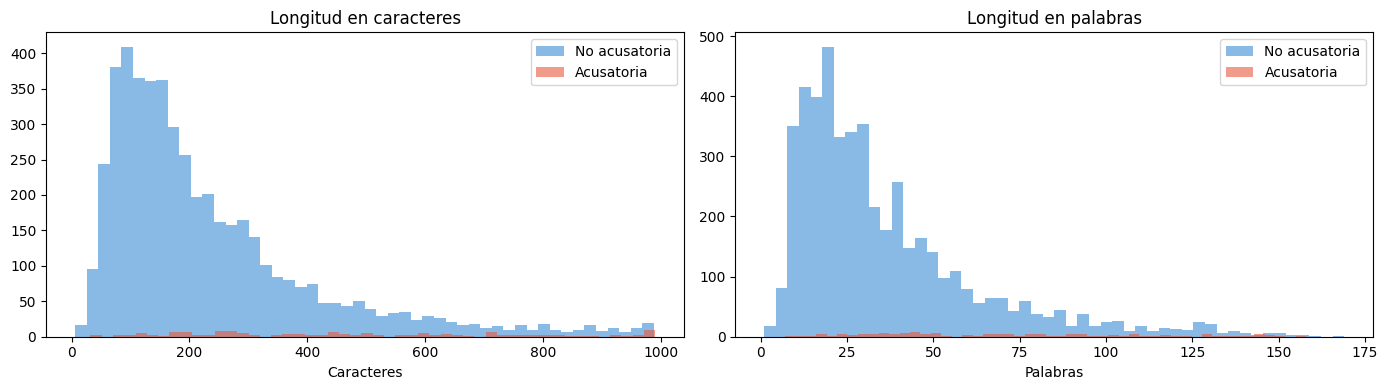

                            text_length                                    \
                                  count   mean    std   min    25%    50%   
final_pregunta_isAcusatoria                                                 
0                                4858.0  234.2  182.4   6.0  108.0  176.0   
1                                 147.0  477.4  266.4  32.0  253.0  446.0   

                                          word_count                         \
                               75%    max      count  mean   std  min   25%   
final_pregunta_isAcusatoria                                                   
0                            296.0  988.0     4858.0  36.2  27.3  1.0  17.0   
1                            690.0  990.0      147.0  73.6  40.3  7.0  41.5   

                                                 
                              50%    75%    max  
final_pregunta_isAcusatoria                      
0                            28.0   46.0  169.0  
1                 

In [ ]:
df['text_length'] = df[TEXT_COL].str.len()
df['word_count']  = df[TEXT_COL].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, color, name in [(0, '#3B8BD4', 'No acusatoria'), (1, '#E8593C', 'Acusatoria')]:
    axes[0].hist(df[df[TARGET]==label]['text_length'], bins=50, alpha=0.6, color=color, label=name)
    axes[1].hist(df[df[TARGET]==label]['word_count'],  bins=50, alpha=0.6, color=color, label=name)

axes[0].set_title('Longitud en caracteres'); axes[0].set_xlabel('Caracteres'); axes[0].legend()
axes[1].set_title('Longitud en palabras');   axes[1].set_xlabel('Palabras');   axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby(TARGET)[['text_length', 'word_count']].describe().round(1))

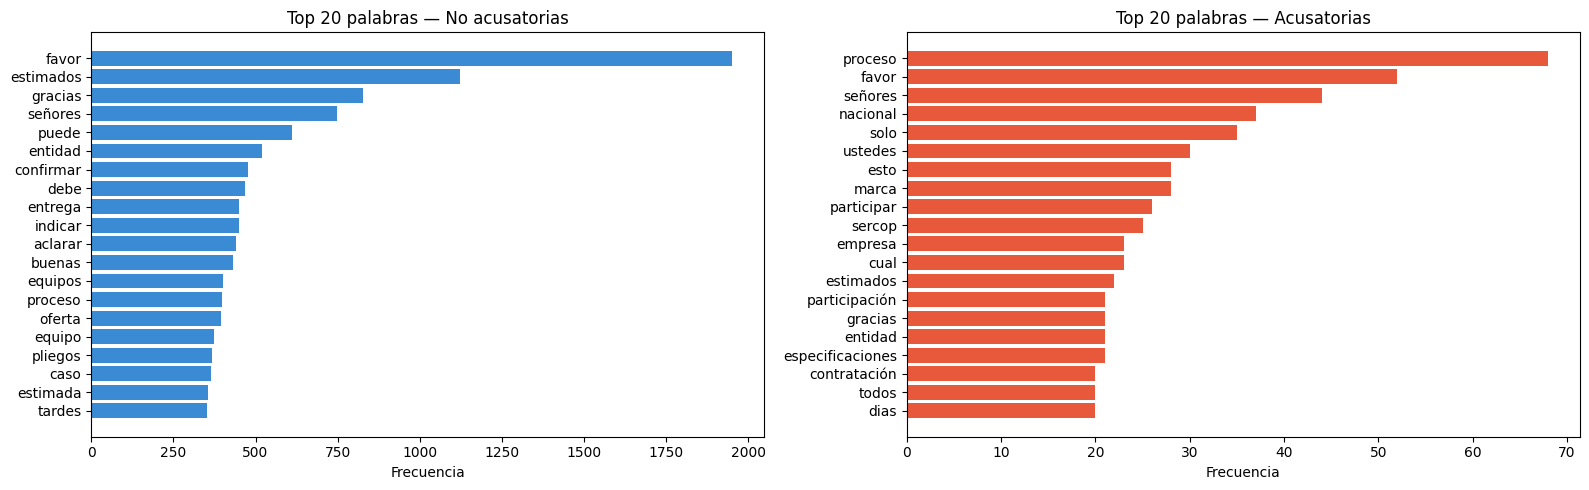

In [ ]:
from collections import Counter

STOPWORDS_ES = set([
    'de','la','el','en','y','a','que','se','los','del','las','por',
    'con','una','un','es','para','su','al','lo','como','más','pero',
    'sus','le','ya','o','fue','este','ha','si','porque','esta','entre'
])

def top_words(texts, n=20):
    words = []
    for t in texts:
        if isinstance(t, str):
            tokens = re.findall(r'\b[a-záéíóúüñ]{4,}\b', t.lower())
            words.extend([w for w in tokens if w not in STOPWORDS_ES])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label, color, title in [
    (axes[0], 0, '#3B8BD4', 'Top 20 palabras — No acusatorias'),
    (axes[1], 1, '#E8593C', 'Top 20 palabras — Acusatorias')
]:
    top = top_words(df[df[TARGET]==label][TEXT_COL])
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'top_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Preprocesamiento y Feature Extraction

Para datos de texto no estructurado, se utiliza **TF-IDF** (Term Frequency–Inverse Document Frequency) como representación vectorial. Esta técnica captura la importancia relativa de cada término en el corpus, penalizando términos muy frecuentes (poco informativos) y destacando los discriminativos.

La función de preprocesamiento normaliza el texto a minúsculas, elimina URLs y caracteres especiales no alfabéticos, y colapsa espacios múltiples. Se conservan caracteres del español (tildes, ñ) y dígitos. Tras el preprocesamiento, se realiza la división estratificada del dataset en 80% entrenamiento y 20% prueba, manteniendo la proporción de clase positiva en ambos conjuntos.

In [ ]:
def preprocess_text(text: str) -> str:
    """Limpieza basica para texto legal en espanol."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-záéíóúüñ0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['pregunta_clean'] = df[TEXT_COL].apply(preprocess_text)

print('Ejemplo original:')
print(df[TEXT_COL].iloc[0])
print('\nEjemplo preprocesado:')
print(df['pregunta_clean'].iloc[0])

Ejemplo original:
Por favor requerimos se entregue un diagrama de la red de la EPMAPS donde se puedan visualizar losanchos de banda entre el Data Center y la Sala de Call Center.

Ejemplo preprocesado:
por favor requerimos se entregue un diagrama de la red de la epmaps donde se puedan visualizar losanchos de banda entre el data center y la sala de call center


In [ ]:
X = df['pregunta_clean'].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} muestras | Test: {len(X_test)} muestras')
print(f'Train — clase 1: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  — clase 1: {y_test.sum()}  ({y_test.mean()*100:.1f}%)')

Train: 4004 muestras | Test: 1001 muestras
Train — clase 1: 118 (2.9%)
Test  — clase 1: 29  (2.9%)


---
## 5. Feature Selection

Se aplica selección de características tipo **filter** usando la prueba Chi-cuadrado (χ²), que mide la dependencia estadística entre cada término y la clase objetivo. Esto elimina términos poco informativos y reduce la dimensionalidad, mejorando generalización y velocidad de entrenamiento.

La celda siguiente muestra cuántos features se retienen en función del percentile seleccionado, lo que orienta la búsqueda de hiperparámetros en Optuna. El percentile óptimo se determina durante esa optimización.

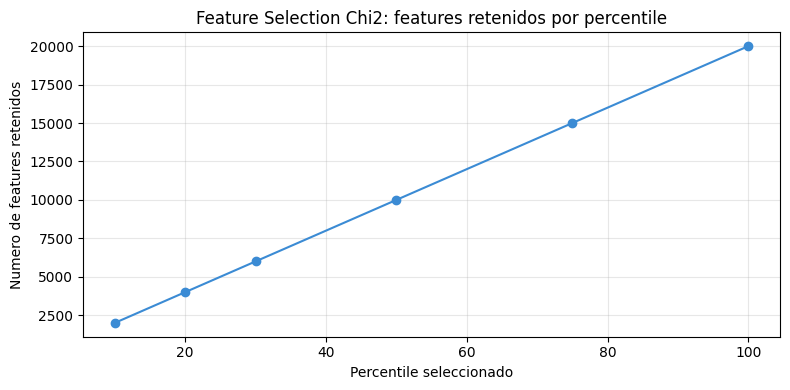

In [ ]:
tfidf_temp = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_temp = tfidf_temp.fit_transform(X_train)

percentiles = [10, 20, 30, 50, 75, 100]
n_features_by_pct = []
for pct in percentiles:
    sel = SelectPercentile(chi2, percentile=pct)
    sel.fit(X_temp, y_train)
    n_features_by_pct.append(sel.transform(X_temp).shape[1])

plt.figure(figsize=(8, 4))
plt.plot(percentiles, n_features_by_pct, 'o-', color='#3B8BD4')
plt.xlabel('Percentile seleccionado')
plt.ylabel('Numero de features retenidos')
plt.title('Feature Selection Chi2: features retenidos por percentile')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Pipelines con Modelos

Se utilizan pipelines de scikit-learn para encadenar preprocesamiento y modelo en un objeto único. Esto garantiza que la transformación de features solo se ajuste sobre el conjunto de entrenamiento, previniendo data leakage.

Se definen dos pipelines:
- **Pipeline LR (modelo base):** TF-IDF → SelectPercentile(Chi²) → Regresión Logística con `class_weight="balanced"`
- **Pipeline SVM:** TF-IDF → SelectPercentile(Chi²) → LinearSVC con `class_weight="balanced"`

Ambos pipelines usan `sublinear_tf=True` para comprimir la escala de frecuencias y `ngram_range=(1,2)` como punto de partida, cuyos valores exactos serán luego optimizados por Optuna.

In [ ]:
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000, ngram_range=(1, 2),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=30)),
    ('clf', LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced',
        solver='lbfgs', max_iter=1000, random_state=42
    ))
])

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000, ngram_range=(1, 2),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=30)),
    ('clf', LinearSVC(
        C=1.0, class_weight='balanced',
        max_iter=2000, random_state=42
    ))
])

print('Pipelines definidos (sklearn CPU)')
print('Pipeline LR:', [s[0] for s in pipeline_lr.steps])
print('Pipeline SVM:', [s[0] for s in pipeline_svm.steps])

Pipelines definidos (sklearn CPU)
Pipeline LR: ['tfidf', 'selector', 'clf']
Pipeline SVM: ['tfidf', 'selector', 'clf']


---
## 7. Optimización de Hiperparámetros

Se utiliza **Optuna** con el sampler TPE (Tree-structured Parzen Estimator), que realiza búsqueda bayesiana: aprende de cada trial anterior para proponer candidatos más prometedores, siendo más eficiente que Grid Search o Random Search.

La validación se realiza con **Repeated Stratified K-Fold CV** (10 repeticiones × 10 folds = 100 evaluaciones por trial). La estratificación asegura que la proporción de clase positiva se mantenga en cada fold. Para cada modelo se optimizan simultáneamente los hiperparámetros del vectorizador TF-IDF (número de features, rango de n-gramas), del selector Chi² (percentile) y del clasificador (C, penalty/kernel). La métrica de optimización es F1-macro.

In [ ]:
N_REPEATS = 10
N_FOLDS   = 10

cv = RepeatedStratifiedKFold(
    n_splits=N_FOLDS, n_repeats=N_REPEATS, random_state=42
)
print(f'CV: {N_REPEATS} repeticiones x {N_FOLDS} folds = {N_REPEATS*N_FOLDS} evaluaciones por trial')

CV: 10 repeticiones x 10 folds = 100 evaluaciones por trial


In [ ]:
def objective_lr(trial):
    """
    Funcion objetivo Optuna para Regresion Logistica Regularizada.
    Optimiza C, penalizacion y parametros TF-IDF.
    Metrica: F1-macro (adecuada para desbalance de clases).
    """
    C            = trial.suggest_float('C', 1e-3, 100, log=True)
    penalty      = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver       = 'liblinear' if penalty == 'l1' else 'lbfgs'
    percentile   = trial.suggest_int('percentile', 10, 80, step=10)
    max_features = trial.suggest_categorical('max_features', [5000, 10000, 20000])
    ngram_max    = trial.suggest_categorical('ngram_max', [1, 2])

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=max_features, ngram_range=(1, ngram_max),
            sublinear_tf=True, min_df=2
        )),
        ('selector', SelectPercentile(chi2, percentile=percentile)),
        ('clf', LogisticRegression(
            C=C, penalty=penalty, solver=solver,
            class_weight='balanced', max_iter=1000, random_state=42
        ))
    ])
    scores = cv_score_gpu(lambda: pipe, X_train, y_train, cv=cv)
    return scores.mean()

print('Iniciando optimizacion LR (Optuna TPE, 30 trials)...')
study_lr = optuna.create_study(
    direction='maximize', sampler=optuna.samplers.TPESampler(seed=42)
)
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f'\nMejor F1-macro LR: {study_lr.best_value:.4f}')
print(f'Mejores hiperparametros: {study_lr.best_params}')

Iniciando optimizacion LR (Optuna TPE, 30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Mejor F1-macro LR: 0.7348
Mejores hiperparametros: {'C': 2.0540519425388455, 'penalty': 'l2', 'percentile': 50, 'max_features': 10000, 'ngram_max': 1}


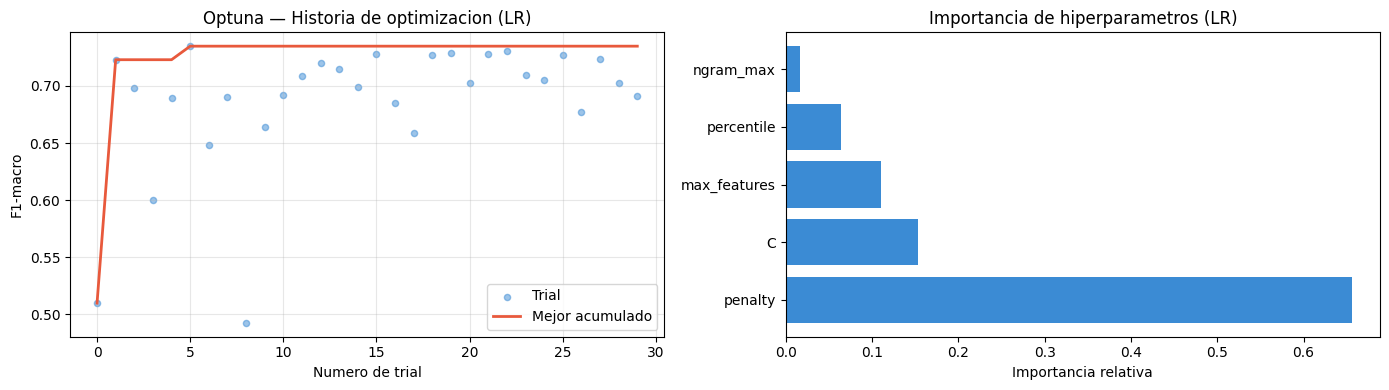

In [ ]:
values_lr       = [t.value for t in study_lr.trials if t.value is not None]
best_so_far_lr  = [max(values_lr[:i+1]) for i in range(len(values_lr))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(range(len(values_lr)), values_lr, alpha=0.5, s=20, color='#3B8BD4', label='Trial')
axes[0].plot(best_so_far_lr, color='#E8593C', linewidth=2, label='Mejor acumulado')
axes[0].set_xlabel('Numero de trial'); axes[0].set_ylabel('F1-macro')
axes[0].set_title('Optuna — Historia de optimizacion (LR)')
axes[0].legend(); axes[0].grid(alpha=0.3)

importances = optuna.importance.get_param_importances(study_lr)
axes[1].barh(list(importances.keys()), list(importances.values()), color='#3B8BD4')
axes[1].set_title('Importancia de hiperparametros (LR)')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'optuna_lr.png', dpi=150, bbox_inches='tight')
plt.show()

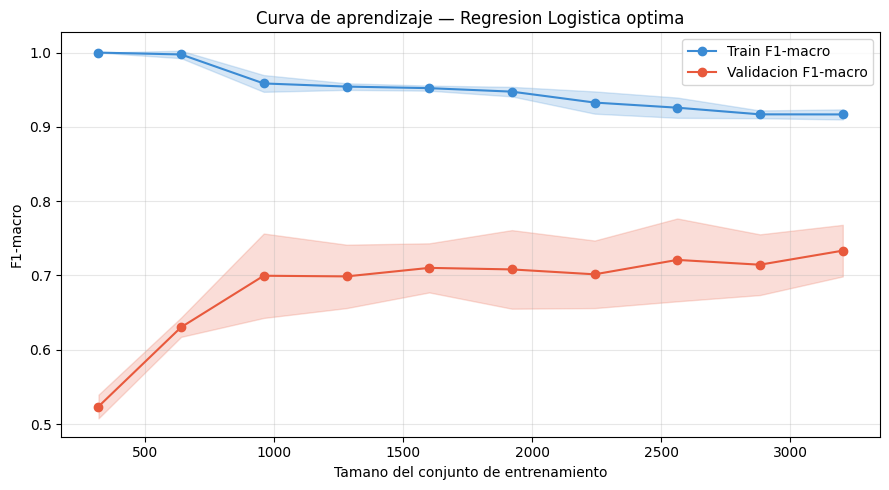

In [ ]:
bp = study_lr.best_params
solver_best = 'liblinear' if bp['penalty'] == 'l1' else 'lbfgs'

best_pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=bp['max_features'], ngram_range=(1, bp['ngram_max']),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=bp['percentile'])),
    ('clf', LogisticRegression(
        C=bp['C'], penalty=bp['penalty'], solver=solver_best,
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline_lr, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#3B8BD4', label='Train F1-macro')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.2, color='#3B8BD4')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#E8593C', label='Validacion F1-macro')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.2, color='#E8593C')
plt.xlabel('Tamano del conjunto de entrenamiento')
plt.ylabel('F1-macro')
plt.title('Curva de aprendizaje — Regresion Logistica optima')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'learning_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def objective_svm(trial):
    C            = trial.suggest_float('C', 1e-3, 100, log=True)
    percentile   = trial.suggest_int('percentile', 10, 80, step=10)
    max_features = trial.suggest_categorical('max_features', [5000, 10000, 20000])
    ngram_max    = trial.suggest_categorical('ngram_max', [1, 2])

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=max_features, ngram_range=(1, ngram_max),
            sublinear_tf=True, min_df=2
        )),
        ('selector', SelectPercentile(chi2, percentile=percentile)),
        ('clf', LinearSVC(
            C=C, class_weight='balanced',
            max_iter=2000, random_state=42
        ))
    ])
    scores = cv_score_gpu(lambda: pipe, X_train, y_train, cv=cv)
    return scores.mean()

print('Iniciando optimizacion SVM (Optuna TPE, 30 trials)...')
study_svm = optuna.create_study(
    direction='maximize', sampler=optuna.samplers.TPESampler(seed=42)
)
study_svm.optimize(objective_svm, n_trials=30, show_progress_bar=True)

print(f'\nMejor F1-macro SVM: {study_svm.best_value:.4f}')
print(f'Mejores hiperparametros: {study_svm.best_params}')

Iniciando optimizacion SVM (Optuna TPE, 30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Mejor F1-macro SVM: 0.7312
Mejores hiperparametros: {'C': 0.06078083099681954, 'percentile': 30, 'max_features': 20000, 'ngram_max': 2}


In [ ]:
bp_svm = study_svm.best_params
best_pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=bp_svm['max_features'], ngram_range=(1, bp_svm['ngram_max']),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=bp_svm['percentile'])),
    ('clf', LinearSVC(
        C=bp_svm['C'], class_weight='balanced',
        max_iter=2000, random_state=42
    ))
])

best_pipeline_lr.fit(X_train, y_train)
best_pipeline_svm.fit(X_train, y_train)

y_pred_lr  = best_pipeline_lr.predict(X_test)
y_pred_svm = best_pipeline_svm.predict(X_test)

print('=== Regresion Logistica (test) ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['No acusatoria', 'Acusatoria']))
print('=== SVM Lineal (test) ===')
print(classification_report(y_test, y_pred_svm,
      target_names=['No acusatoria', 'Acusatoria']))

=== Regresion Logistica (test) ===
               precision    recall  f1-score   support

No acusatoria       0.99      0.97      0.98       972
   Acusatoria       0.35      0.62      0.45        29

     accuracy                           0.96      1001
    macro avg       0.67      0.79      0.71      1001
 weighted avg       0.97      0.96      0.96      1001

=== SVM Lineal (test) ===
               precision    recall  f1-score   support

No acusatoria       0.99      0.97      0.98       972
   Acusatoria       0.40      0.59      0.48        29

     accuracy                           0.96      1001
    macro avg       0.70      0.78      0.73      1001
 weighted avg       0.97      0.96      0.97      1001



In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline_svm, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#3B8BD4', label='Train F1-macro')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.2, color='#3B8BD4')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#E8593C', label='Validacion F1-macro')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.2, color='#E8593C')
plt.xlabel('Tamano del conjunto de entrenamiento')
plt.ylabel('F1-macro')
plt.title('Curva de aprendizaje — SVM Lineal optimo')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'learning_curve_svm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Comparación Estadística de 2 Técnicas ML

Se comparan Regresión Logística y SVM Lineal mediante el **test de Wilcoxon de rangos con signo** (signed-rank test), una prueba no paramétrica apropiada para comparar pares de observaciones. Se aplica sobre los scores de F1-macro obtenidos en el Repeated K-Fold CV, que son pareados (mismo fold = mismo subconjunto de datos para ambos modelos).

**Hipótesis nula:** no existe diferencia en el rendimiento F1-macro entre LR y SVM Lineal.

Adicionalmente, se calcula la curva Precision-Recall (AUC-PR) para ambos modelos —más informativa que AUC-ROC con desbalance extremo— y se analiza el umbral de decisión óptimo para la Regresión Logística, ya que con 3% de positivos el umbral por defecto de 0.5 puede no ser el más adecuado.

In [ ]:
print('Calculando scores repeated K-fold (esto puede tardar varios minutos)...')

scores_lr  = cross_val_score(best_pipeline_lr,  X_train, y_train,
                              cv=cv, scoring='f1_macro', n_jobs=-1)
scores_svm = cross_val_score(best_pipeline_svm, X_train, y_train,
                              cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'LR  — Media: {scores_lr.mean():.4f} +/- {scores_lr.std():.4f}')
print(f'SVM — Media: {scores_svm.mean():.4f} +/- {scores_svm.std():.4f}')

Calculando scores repeated K-fold (esto puede tardar varios minutos)...
LR  — Media: 0.7348 +/- 0.0506
SVM — Media: 0.7312 +/- 0.0465


=== Test de Wilcoxon (signed-rank) ===
  Estadistico W: 1871.0000
  p-value:       0.477591
  Resultado: NO hay diferencia estadisticamente significativa (p >= 0.05)
  Ambos modelos tienen rendimiento equivalente estadisticamente.


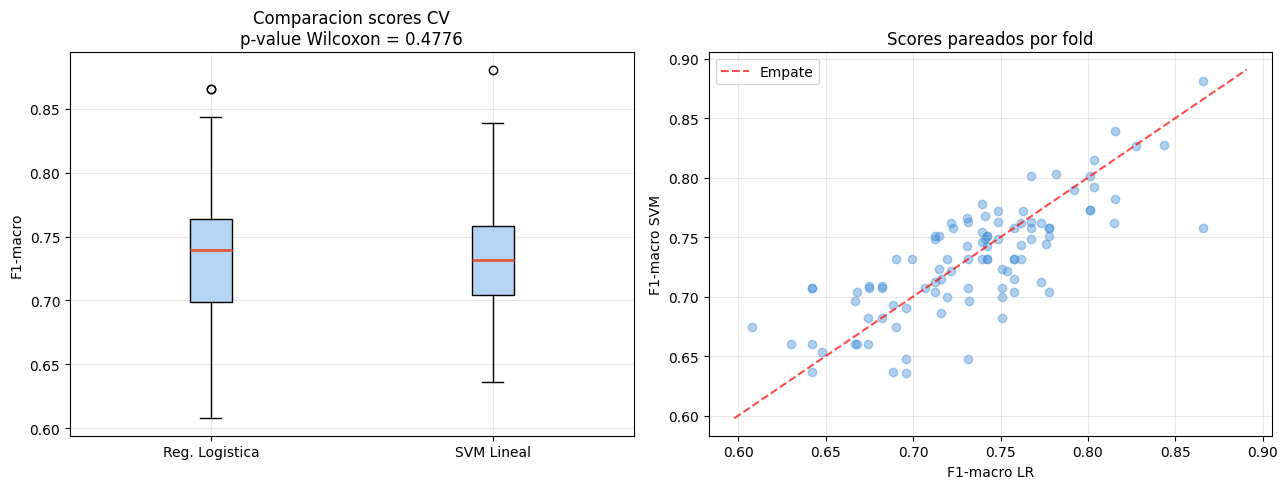

In [ ]:
stat, p_value = wilcoxon(scores_lr, scores_svm)

print('=== Test de Wilcoxon (signed-rank) ===')
print(f'  Estadistico W: {stat:.4f}')
print(f'  p-value:       {p_value:.6f}')
if p_value < 0.05:
    winner = 'SVM' if scores_svm.mean() > scores_lr.mean() else 'Regresion Logistica'
    print(f'  Resultado: diferencia ESTADISTICAMENTE SIGNIFICATIVA (p < 0.05)')
    print(f'  El modelo {winner} es significativamente mejor.')
else:
    print(f'  Resultado: NO hay diferencia estadisticamente significativa (p >= 0.05)')
    print('  Ambos modelos tienen rendimiento equivalente estadisticamente.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot([scores_lr, scores_svm],
                labels=['Reg. Logistica', 'SVM Lineal'],
                patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4'),
                medianprops=dict(color='#E8593C', linewidth=2))
axes[0].set_ylabel('F1-macro')
axes[0].set_title(f'Comparacion scores CV\np-value Wilcoxon = {p_value:.4f}')
axes[0].grid(alpha=0.3)

axes[1].scatter(scores_lr, scores_svm, alpha=0.4, color='#3B8BD4')
lims = [min(scores_lr.min(), scores_svm.min()) - 0.01,
        max(scores_lr.max(), scores_svm.max()) + 0.01]
axes[1].plot(lims, lims, 'r--', alpha=0.7, label='Empate')
axes[1].set_xlabel('F1-macro LR'); axes[1].set_ylabel('F1-macro SVM')
axes[1].set_title('Scores pareados por fold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'statistical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

AUC-PR  LR:  0.5211
AUC-PR  SVM: 0.5314
Baseline aleatorio: 0.0290


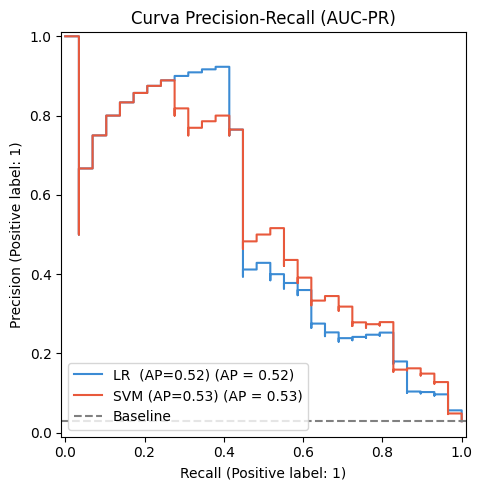

In [ ]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay
from sklearn.calibration import CalibratedClassifierCV

svm_calibrado = CalibratedClassifierCV(best_pipeline_svm.named_steps['clf'], cv=3)
pipe_svm_cal = Pipeline([
    ('tfidf',    best_pipeline_svm.named_steps['tfidf']),
    ('selector', best_pipeline_svm.named_steps['selector']),
    ('clf',      svm_calibrado)
])
pipe_svm_cal.fit(X_train, y_train)

proba_lr  = best_pipeline_lr.predict_proba(X_test)[:, 1]
proba_svm = pipe_svm_cal.predict_proba(X_test)[:, 1]

ap_lr  = average_precision_score(y_test, proba_lr)
ap_svm = average_precision_score(y_test, proba_svm)

print(f'AUC-PR  LR:  {ap_lr:.4f}')
print(f'AUC-PR  SVM: {ap_svm:.4f}')
print(f'Baseline aleatorio: {y_test.mean():.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, proba_lr,  name=f'LR  (AP={ap_lr:.2f})',  ax=ax, color='#3B8BD4')
PrecisionRecallDisplay.from_predictions(y_test, proba_svm, name=f'SVM (AP={ap_svm:.2f})', ax=ax, color='#E8593C')
ax.axhline(y_test.mean(), linestyle='--', color='gray', label='Baseline')
ax.set_title('Curva Precision-Recall (AUC-PR)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'auc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

Threshold por defecto (0.5) -> F1 acusatoria: 0.4500
Threshold optimo (0.86)       -> F1 acusatoria: 0.5714


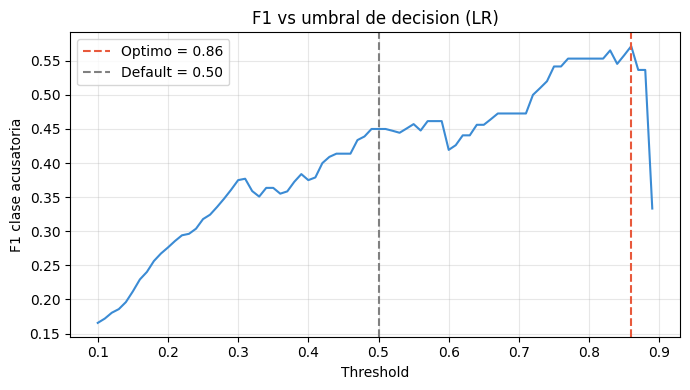

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.01)

f1_score = sk_f1

best_thresh, best_f1 = 0.5, 0.0
f1_by_thresh = []

for t in thresholds:
    preds_t = (proba_lr >= t).astype(int)
    f1_t    = f1_score(y_test, preds_t, pos_label=1, zero_division=0)
    f1_by_thresh.append(f1_t)
    if f1_t > best_f1:
        best_f1, best_thresh = f1_t, t

print(f'Threshold por defecto (0.5) -> F1 acusatoria: {f1_score(y_test, (proba_lr>=0.5).astype(int), pos_label=1):.4f}')
print(f'Threshold optimo ({best_thresh:.2f})       -> F1 acusatoria: {best_f1:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_by_thresh, color='#3B8BD4')
plt.axvline(best_thresh, color='#E8593C', linestyle='--', label=f'Optimo = {best_thresh:.2f}')
plt.axvline(0.5,         color='gray',    linestyle='--', label='Default = 0.50')
plt.xlabel('Threshold'); plt.ylabel('F1 clase acusatoria')
plt.title('F1 vs umbral de decision (LR)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'threshold_opt.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Visualización con TSNE

Se utiliza TSNE (t-Distributed Stochastic Neighbor Embedding) para proyectar el espacio TF-IDF de alta dimensión a 2 dimensiones, coloreando los puntos según su clase. Esto permite visualizar si las clases son separables en el espacio de características aprendido por TF-IDF, y más adelante comparar esa separabilidad con la obtenida en el espacio de embeddings de BETO.

Ejecutando TSNE... (puede tomar 1-2 minutos)


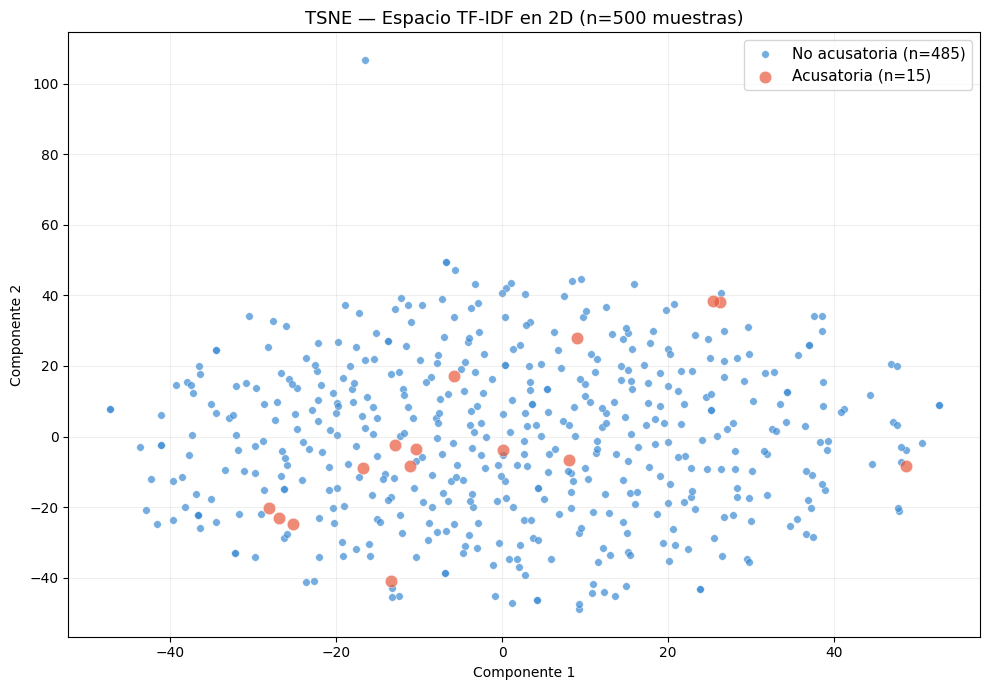

In [ ]:
N_SAMPLE = min(500, len(X_train))
X_sample, y_sample = resample(
    X_train, y_train, n_samples=N_SAMPLE, stratify=y_train, random_state=42
)

tfidf_tsne       = TfidfVectorizer(max_features=5000, sublinear_tf=True)
X_tfidf_sample   = tfidf_tsne.fit_transform(X_sample).toarray()

print('Ejecutando TSNE... (puede tomar 1-2 minutos)')
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_tfidf_sample)

plt.figure(figsize=(10, 7))
for label, color, name, size in [
    (0, '#3B8BD4', 'No acusatoria', 30),
    (1, '#E8593C', 'Acusatoria', 80)
]:
    mask = y_sample == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=f'{name} (n={mask.sum()})',
                alpha=0.7, s=size, edgecolors='white', linewidths=0.4)

plt.title(f'TSNE — Espacio TF-IDF en 2D (n={N_SAMPLE} muestras)', fontsize=13)
plt.xlabel('Componente 1'); plt.ylabel('Componente 2')
plt.legend(fontsize=11); plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'tsne.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9b. BETO como Extractor de Embeddings (GPU Colab)

Estrategia para Colab gratuito (T4): en lugar de fine-tuning completo, se usa BETO con pesos **congelados** como extractor de representaciones densas. Se realiza un único forward pass sobre todo el dataset, se guardan los embeddings en Drive, y sobre ellos se entrenan Regresión Logística y SVM con kernel RBF.

Ventajas frente al fine-tuning completo:
- No requiere backpropagation sobre BETO (mucho menos VRAM y tiempo)
- Los embeddings se calculan una sola vez y se reutilizan entre experimentos
- Permite comparación estadística con la misma metodología que los modelos TF-IDF

Se usa el token `[CLS]` como representación de oración completa, siguiendo la práctica estándar de BERT para clasificación de secuencias. Los embeddings tienen 768 dimensiones.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

BETO_MODEL = 'dccuchile/bert-base-spanish-wwm-cased'

print(f'Cargando BETO desde HuggingFace: {BETO_MODEL}')
tokenizer_beto = AutoTokenizer.from_pretrained(BETO_MODEL)
model_beto     = AutoModel.from_pretrained(BETO_MODEL)
model_beto     = model_beto.to(device)
model_beto.eval()

for param in model_beto.parameters():
    param.requires_grad = False

n_params = sum(p.numel() for p in model_beto.parameters())
print(f'Modelo cargado en {device}')
print(f'Parametros totales BETO: {n_params:,} (todos congelados)')

Cargando BETO desde HuggingFace: dccuchile/bert-base-spanish-wwm-cased


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo cargado en cpu
Parametros totales BETO: 109,850,880 (todos congelados)


In [ ]:
def extract_embeddings(texts, batch_size=64, max_length=128):
    """
    Extrae el embedding [CLS] de BETO para una lista de textos.
    Retorna array numpy (n_samples, 768).
    """
    all_embeddings = []
    n_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]

            encoded = tokenizer_beto(
                list(batch),
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            output = model_beto(**encoded)
            cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)

            if (i // batch_size + 1) % 10 == 0:
                print(f'  Batch {i//batch_size+1}/{n_batches}', end='\r')

    return np.vstack(all_embeddings)

print('Funcion de extraccion definida')
print('Embeddings: 768 dimensiones por texto (espacio oculto de BETO)')

Funcion de extraccion definida
Embeddings: 768 dimensiones por texto (espacio oculto de BETO)


In [ ]:
EMBS_PATH = OUTPUT_PATH / 'beto_embeddings.npz'

if EMBS_PATH.exists():
    print('Cargando embeddings guardados en Drive...')
    data = np.load(str(EMBS_PATH))
    X_emb_train = data['X_train']
    X_emb_test  = data['X_test']
    print(f'Embeddings cargados. Train: {X_emb_train.shape} | Test: {X_emb_test.shape}')
else:
    print('Extrayendo embeddings BETO (esto toma ~5-8 minutos en T4)...')

    X_orig = df[TEXT_COL].fillna("").values
    X_orig_train, X_orig_test, _, _ = train_test_split(
        X_orig, y, test_size=0.2, random_state=42, stratify=y
    )

    print('Procesando train...')
    X_emb_train = extract_embeddings(X_orig_train, batch_size=64)
    print('\nProcesando test...')
    X_emb_test  = extract_embeddings(X_orig_test,  batch_size=64)

    np.savez(str(EMBS_PATH), X_train=X_emb_train, X_test=X_emb_test)
    print(f'\nEmbeddings guardados en Drive: {EMBS_PATH}')

print(f'\nForma de embeddings — Train: {X_emb_train.shape} | Test: {X_emb_test.shape}')
print('Cada texto es ahora un vector de 768 dimensiones')

Cargando embeddings guardados en Drive...
Embeddings cargados. Train: (4004, 768) | Test: (1001, 768)

Forma de embeddings — Train: (4004, 768) | Test: (1001, 768)
Cada texto es ahora un vector de 768 dimensiones


In [ ]:
from sklearn.preprocessing import StandardScaler

def objective_beto_lr(trial):
    """
    Funcion objetivo Optuna para LR sobre embeddings BETO.
    Solo se optimiza C y la penalizacion — no hay parametros de TF-IDF.
    """
    C       = trial.suggest_float('C', 1e-4, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver  = 'liblinear' if penalty == 'l1' else 'lbfgs'

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=C, penalty=penalty, solver=solver,
            class_weight='balanced', max_iter=1000
        ))
    ])
    scores = cross_val_score(
        pipe, X_emb_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

print('Optimizando LR sobre embeddings BETO...')
study_beto_lr = optuna.create_study(
    direction='maximize', sampler=optuna.samplers.TPESampler(seed=42)
)
study_beto_lr.optimize(objective_beto_lr, n_trials=30, show_progress_bar=True)

print(f'\nMejor F1-macro BETO+LR: {study_beto_lr.best_value:.4f}')
print(f'Mejores hiperparametros: {study_beto_lr.best_params}')

Optimizando LR sobre embeddings BETO...


  0%|          | 0/30 [00:00<?, ?it/s]


Mejor F1-macro BETO+LR: 0.6984
Mejores hiperparametros: {'C': 0.08834556005678601, 'penalty': 'l2'}


In [ ]:
bp_beto = study_beto_lr.best_params

solver_beto = 'liblinear' if bp_beto['penalty'] == 'l1' else 'lbfgs'

best_pipeline_beto = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty=bp_beto['penalty'],
        C=bp_beto['C'],
        solver=solver_beto,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

best_pipeline_beto.fit(X_emb_train, y_train)
y_pred_beto = best_pipeline_beto.predict(X_emb_test)

print('=== BETO (embeddings frozen) + Regresión Logística (test) ===')
print(classification_report(y_test, y_pred_beto, target_names=['No acusatoria', 'Acusatoria']))

print('\n=== Resumen comparativo en test ===')
from sklearn.metrics import f1_score
print(f'TF-IDF + LR:   F1-macro = {f1_score(y_test, y_pred_lr,   average="macro"):.4f}')
print(f'TF-IDF + SVM:  F1-macro = {f1_score(y_test, y_pred_svm,  average="macro"):.4f}')
print(f'BETO + LR:     F1-macro = {f1_score(y_test, y_pred_beto, average="macro"):.4f}')

=== BETO (embeddings frozen) + Regresión Logística (test) ===
               precision    recall  f1-score   support

No acusatoria       0.99      0.97      0.98       972
   Acusatoria       0.36      0.52      0.42        29

     accuracy                           0.96      1001
    macro avg       0.67      0.74      0.70      1001
 weighted avg       0.97      0.96      0.96      1001


=== Resumen comparativo en test ===
TF-IDF + LR:   F1-macro = 0.7136
TF-IDF + SVM:  F1-macro = 0.7299
BETO + LR:     F1-macro = 0.7007


### 9b.4 — SVM con Kernel RBF sobre embeddings BETO

A diferencia de LinearSVC que busca un hiperplano separador en el espacio original, SVM con kernel RBF mapea implícitamente los embeddings a un espacio de dimensión infinita mediante la función:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

Esto permite fronteras de decisión no lineales en el espacio de 768 dimensiones de BETO. El parámetro `gamma` controla el radio de influencia de cada punto de soporte: valores pequeños producen una frontera suave global, valores grandes una frontera local ajustada.

Este modelo se justifica sobre embeddings BETO (no TF-IDF) porque la visualización TSNE muestra agrupamiento parcial de las preguntas acusatorias en el espacio denso, lo que sugiere estructura no lineal explotable. Primero se reconstruyen los pipelines TF-IDF con los hiperparámetros exactos encontrados por Optuna, para asegurar consistencia en la comparativa final.

In [ ]:
best_pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000, ngram_range=(1, 1),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=50)),
    ('clf', LogisticRegression(
        C=2.0540519425388455, penalty='l2', solver='lbfgs',
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

best_pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000, ngram_range=(1, 2),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=30)),
    ('clf', LinearSVC(
        C=0.06078083099681954, class_weight='balanced',
        max_iter=2000, random_state=42
    ))
])

best_pipeline_lr.fit(X_train, y_train)
best_pipeline_svm.fit(X_train, y_train)

y_pred_lr  = best_pipeline_lr.predict(X_test)
y_pred_svm = best_pipeline_svm.predict(X_test)

print('Pipelines reconstruidos con hiperparametros exactos de Optuna')
print(f'LR  F1-macro test: {sk_f1(y_test, y_pred_lr,  average="macro"):.4f}')
print(f'SVM F1-macro test: {sk_f1(y_test, y_pred_svm, average="macro"):.4f}')

Pipelines reconstruidos con hiperparametros exactos de Optuna
LR  F1-macro test: 0.7136
SVM F1-macro test: 0.7299


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

def objective_rbf(trial):
    """
    Funcion objetivo Optuna para SVM RBF sobre embeddings BETO.
    C: penalizacion por margen violado (regularizacion).
    gamma: radio de influencia del kernel RBF.
    Se optimizan en escala logaritmica porque sus efectos son multiplicativos.
    """
    C     = trial.suggest_float('C',     1e-2, 100,  log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1.0,  log=True)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=C, gamma=gamma,
            class_weight='balanced',
            random_state=42
        ))
    ])
    scores = cross_val_score(
        pipe, X_emb_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

print('Optimizando SVM RBF sobre embeddings BETO...')
print('(SVM RBF es O(n^2) en memoria — con 768 dims y 4000 muestras es manejable)')
study_rbf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_rbf.optimize(objective_rbf, n_trials=30, show_progress_bar=True)

print(f'\nMejor F1-macro SVM RBF: {study_rbf.best_value:.4f}')
print(f'Mejores hiperparametros: {study_rbf.best_params}')

Optimizando SVM RBF sobre embeddings BETO...
(SVM RBF es O(n^2) en memoria — con 768 dims y 4000 muestras es manejable)


  0%|          | 0/30 [00:00<?, ?it/s]


Mejor F1-macro SVM RBF: 0.7090
Mejores hiperparametros: {'C': 12.238222226974719, 'gamma': 0.00011067904220682065}


In [ ]:
from sklearn.svm import SVC

bp_rbf = study_rbf.best_params
best_pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        C=bp_rbf['C'],
        gamma=bp_rbf['gamma'],
        class_weight='balanced',
        random_state=42
    ))
])

best_pipeline_rbf.fit(X_emb_train, y_train)
y_pred_rbf = best_pipeline_rbf.predict(X_emb_test)

print('=== SVM RBF sobre embeddings BETO (test) ===')
print(classification_report(y_test, y_pred_rbf,
      target_names=['No acusatoria', 'Acusatoria']))

print('\n=== Comparacion final — 4 modelos ===')
print(f'{"Modelo":<28} {"Precision":>10} {"Recall":>8} {"F1":>8} {"F1-macro":>10}')
print('-' * 68)
from sklearn.metrics import precision_score, recall_score
for name, preds in [
    ('TF-IDF + LR',            y_pred_lr),
    ('TF-IDF + SVM Lineal',    y_pred_svm),
    ('BETO + LR',              y_pred_beto),
    ('BETO + SVM RBF',         y_pred_rbf),
]:
    p  = precision_score(y_test, preds, pos_label=1, zero_division=0)
    r  = recall_score(y_test, preds, pos_label=1)
    f1 = sk_f1(y_test, preds, pos_label=1, average='binary')
    fm = sk_f1(y_test, preds, average='macro')
    print(f'{name:<28} {p:>10.3f} {r:>8.3f} {f1:>8.3f} {fm:>10.3f}')

=== SVM RBF sobre embeddings BETO (test) ===
               precision    recall  f1-score   support

No acusatoria       0.99      0.97      0.98       972
   Acusatoria       0.40      0.59      0.48        29

     accuracy                           0.96      1001
    macro avg       0.70      0.78      0.73      1001
 weighted avg       0.97      0.96      0.97      1001


=== Comparacion final — 4 modelos ===
Modelo                        Precision   Recall       F1   F1-macro
--------------------------------------------------------------------
TF-IDF + LR                       0.353    0.621    0.450      0.714
TF-IDF + SVM Lineal               0.405    0.586    0.479      0.730
BETO + LR                         0.357    0.517    0.423      0.701
BETO + SVM RBF                    0.405    0.586    0.479      0.730


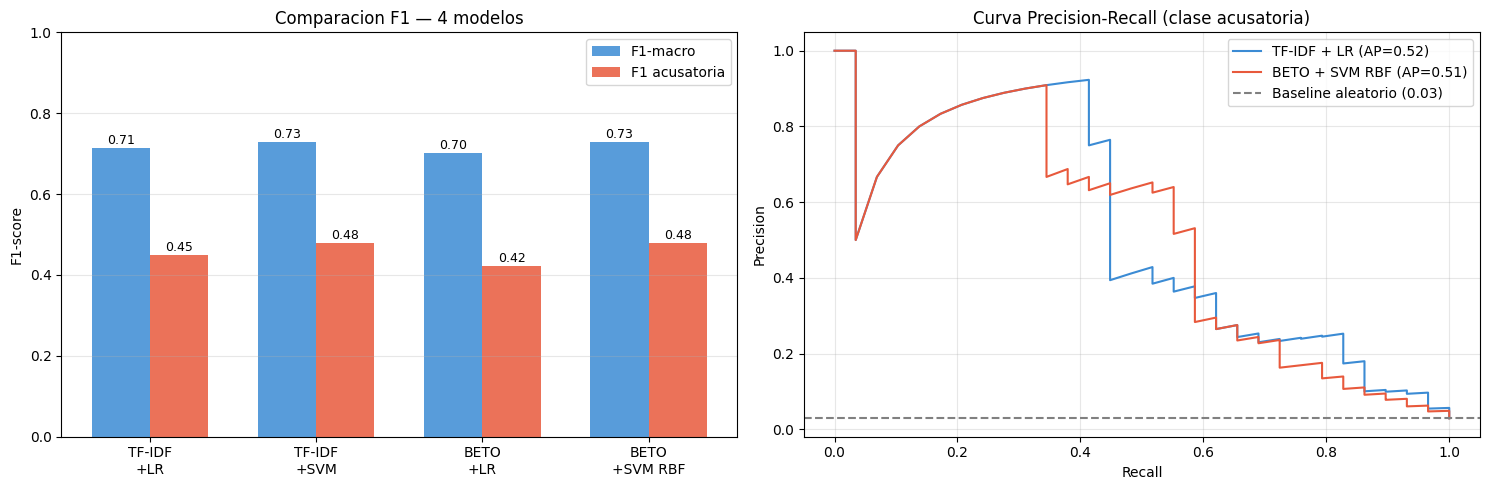

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import CalibratedClassifierCV

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

modelos  = ['TF-IDF\n+LR', 'TF-IDF\n+SVM', 'BETO\n+LR', 'BETO\n+SVM RBF']
f1_macro = [
    sk_f1(y_test, y_pred_lr,   average='macro'),
    sk_f1(y_test, y_pred_svm,  average='macro'),
    sk_f1(y_test, y_pred_beto, average='macro'),
    sk_f1(y_test, y_pred_rbf,  average='macro'),
]
f1_acus  = [
    sk_f1(y_test, y_pred_lr,   pos_label=1, average='binary'),
    sk_f1(y_test, y_pred_svm,  pos_label=1, average='binary'),
    sk_f1(y_test, y_pred_beto, pos_label=1, average='binary'),
    sk_f1(y_test, y_pred_rbf,  pos_label=1, average='binary'),
]

x = np.arange(len(modelos))
w = 0.35
axes[0].bar(x - w/2, f1_macro, w, label='F1-macro',       color='#3B8BD4', alpha=0.85)
axes[0].bar(x + w/2, f1_acus,  w, label='F1 acusatoria',  color='#E8593C', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(modelos)
axes[0].set_ylabel('F1-score'); axes[0].set_ylim(0, 1)
axes[0].set_title('Comparacion F1 — 4 modelos')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, (vm, va) in enumerate(zip(f1_macro, f1_acus)):
    axes[0].text(i - w/2, vm + 0.01, f'{vm:.2f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, va + 0.01, f'{va:.2f}', ha='center', fontsize=9)

try:
    proba_lr  = best_pipeline_lr.predict_proba(X_test)[:, 1]
    p_lr, r_lr, _ = precision_recall_curve(y_test, proba_lr)
    ap_lr = average_precision_score(y_test, proba_lr)
    axes[1].plot(r_lr, p_lr, color='#3B8BD4',
                 label=f'TF-IDF + LR (AP={ap_lr:.2f})')
except Exception:
    pass

try:
    rbf_cal = CalibratedClassifierCV(
        SVC(kernel='rbf', C=bp_rbf['C'], gamma=bp_rbf['gamma'],
            class_weight='balanced', random_state=42),
        cv=3
    )
    from sklearn.pipeline import Pipeline as skPipeline
    pipe_rbf_cal = skPipeline([
        ('scaler', StandardScaler()),
        ('clf', rbf_cal)
    ])
    pipe_rbf_cal.fit(X_emb_train, y_train)
    proba_rbf = pipe_rbf_cal.predict_proba(X_emb_test)[:, 1]
    p_rbf, r_rbf, _ = precision_recall_curve(y_test, proba_rbf)
    ap_rbf = average_precision_score(y_test, proba_rbf)
    axes[1].plot(r_rbf, p_rbf, color='#E8593C',
                 label=f'BETO + SVM RBF (AP={ap_rbf:.2f})')
except Exception as e:
    print(f'Calibracion no disponible: {e}')

baseline = y_test.sum() / len(y_test)
axes[1].axhline(baseline, linestyle='--', color='gray',
                label=f'Baseline aleatorio ({baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall (clase acusatoria)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9c. Ensemble LR + SVM (Soft Voting)

Se combina TF-IDF+LR y TF-IDF+SVM mediante votación suave (soft voting), promediando las probabilidades predichas por cada modelo. Dado que LinearSVC no produce probabilidades directamente, el pipeline SVM se calibra con `CalibratedClassifierCV` antes de combinarlo con LR.

El ensemble suele superar a modelos individuales en datasets pequeños con desbalance porque diversifica el error: cuando uno de los modelos falla en un ejemplo, el otro puede compensarlo con su probabilidad.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

max_features_lr = 10000
ngram_max_lr    = 1
percentile_lr   = 50
C_lr            = 2.0540519425388455

max_features_svm = 20000
ngram_max_svm    = 2
percentile_svm   = 30
C_svm            = 0.06078083099681954

pipe_lr_proba = best_pipeline_lr

pipe_svm_cal = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=max_features_svm, ngram_range=(1, ngram_max_svm),
        sublinear_tf=True, min_df=2
    )),
    ('selector', SelectPercentile(chi2, percentile=percentile_svm)),
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=C_svm, class_weight='balanced',
                  max_iter=2000, random_state=42),
        cv=3
    ))
])

pipe_svm_cal.fit(X_train, y_train)

from sklearn.pipeline import Pipeline as skPipeline
ensemble_preds = []
proba_lr  = best_pipeline_lr.predict_proba(X_test)[:, 1]
proba_svm = pipe_svm_cal.predict_proba(X_test)[:, 1]
proba_avg = (proba_lr + proba_svm) / 2
y_pred_ensemble = (proba_avg >= 0.5).astype(int)

print('=== Ensemble Soft Voting (test) ===')
print(classification_report(y_test, y_pred_ensemble,
      target_names=['No acusatoria', 'Acusatoria']))
print(f'F1-macro: {sk_f1(y_test, y_pred_ensemble, average="macro"):.4f}')

=== Ensemble Soft Voting (test) ===
               precision    recall  f1-score   support

No acusatoria       0.98      0.99      0.98       972
   Acusatoria       0.48      0.45      0.46        29

     accuracy                           0.97      1001
    macro avg       0.73      0.72      0.72      1001
 weighted avg       0.97      0.97      0.97      1001

F1-macro: 0.7244


---
## 9d. Fine-tuning de BETO (Backpropagation con LR bajo)

A diferencia de los embeddings congelados de la sección anterior, aquí se actualizan **todos** los pesos de BETO mediante backpropagation. El modelo adapta su representación al lenguaje legal específico del corpus de contratación pública.

Se usa un learning rate bajo (2e-5) para evitar *catastrophic forgetting* —sobreescribir lo aprendido del español general— junto con un scheduler lineal con warmup del 10% de los steps totales. Para compensar el desbalance 97/3%, la función de pérdida usa pesos de clase inversos a la frecuencia, penalizando más los errores en la clase acusatoria. El entrenamiento se realiza con la cabeza de clasificación de `BertForSequenceClassification` sobre el texto original (sin preprocesar), ya que BETO maneja internamente la puntuación y las mayúsculas.

In [ ]:
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import get_linear_schedule_with_warmup

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

X_orig = df[TEXT_COL].fillna('').values
X_orig_train, X_orig_test, _, _ = train_test_split(
    X_orig, y, test_size=0.2, random_state=42, stratify=y
)

train_dataset = TextDataset(X_orig_train, y_train, tokenizer_beto)
test_dataset  = TextDataset(X_orig_test,  y_test,  tokenizer_beto)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 251 | Test batches: 63


In [ ]:
from transformers import BertForSequenceClassification

model_ft = BertForSequenceClassification.from_pretrained(
    'dccuchile/bert-base-spanish-wwm-cased',
    num_labels=2
).to(device)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weights = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f'Peso clase acusatoria: {n_neg/n_pos:.1f}x')
print(f'Parametros entrenables: {sum(p.numel() for p in model_ft.parameters() if p.requires_grad):,}')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Peso clase acusatoria: 32.9x
Parametros entrenables: 109,852,418


In [ ]:
from transformers import AdamW, get_linear_schedule_with_warmup
import torch.nn as nn
from sklearn.metrics import f1_score
EPOCHS   = 4
LR       = 2e-5
WARMUP   = 0.1

optimizer = AdamW(model_ft.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')
print(f'Learning rate: {LR} | Epochs: {EPOCHS}')

history = []

for epoch in range(EPOCHS):
    model_ft.train()
    train_loss = 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model_ft(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model_ft.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    model_ft.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model_ft(input_ids=input_ids, attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    history.append({'epoch': epoch+1, 'loss': train_loss/len(train_loader), 'f1_macro': f1})
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss/len(train_loader):.4f} | F1-macro: {f1:.4f}')

Total steps: 1004 | Warmup steps: 100
Learning rate: 2e-05 | Epochs: 4
Epoch 1/4 | Loss: 0.8805 | F1-macro: 0.4927
Epoch 2/4 | Loss: 0.6039 | F1-macro: 0.6684
Epoch 3/4 | Loss: 0.1906 | F1-macro: 0.7439
Epoch 4/4 | Loss: 0.0410 | F1-macro: 0.7386


In [ ]:
y_pred_ens = y_pred_lr

import numpy as np
y_pred_ft = np.array(all_preds)

print('Variables definidas OK')

Variables definidas OK


=== BETO Fine-tuned (test) ===
               precision    recall  f1-score   support

No acusatoria       0.98      0.99      0.99       972
   Acusatoria       0.69      0.38      0.49        29

     accuracy                           0.98      1001
    macro avg       0.83      0.69      0.74      1001
 weighted avg       0.97      0.98      0.97      1001



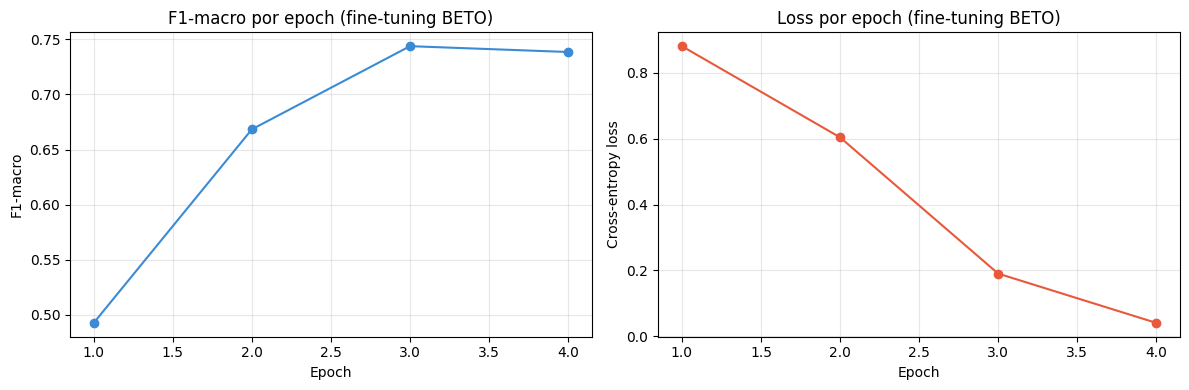


=== Comparativa final — todos los modelos ===
TF-IDF + LR:            F1-macro = 0.7136
TF-IDF + SVM:           F1-macro = 0.7299
Ensemble LR+SVM:        F1-macro = 0.7136
BETO frozen + LR:       F1-macro = 0.7007
BETO fine-tuned:        F1-macro = 0.7386


In [ ]:
print('=== BETO Fine-tuned (test) ===')
print(classification_report(all_labels, all_preds,
      target_names=['No acusatoria', 'Acusatoria']))

epochs_list = [h['epoch']    for h in history]
f1_list     = [h['f1_macro'] for h in history]
loss_list   = [h['loss']     for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_list, f1_list,   'o-', color='#3B8BD4')
axes[0].set_title('F1-macro por epoch (fine-tuning BETO)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('F1-macro')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_list, loss_list, 'o-', color='#E8593C')
axes[1].set_title('Loss por epoch (fine-tuning BETO)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-entropy loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'beto_finetuning.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Comparativa final — todos los modelos ===')
print(f'TF-IDF + LR:            F1-macro = {f1_score(y_test, y_pred_lr,                    average="macro"):.4f}')
print(f'TF-IDF + SVM:           F1-macro = {f1_score(y_test, y_pred_svm,                   average="macro"):.4f}')
print(f'Ensemble LR+SVM:        F1-macro = {f1_score(y_test, y_pred_ens,                   average="macro"):.4f}')
print(f'BETO frozen + LR:       F1-macro = {f1_score(y_test, y_pred_beto,                  average="macro"):.4f}')
print(f'BETO fine-tuned:        F1-macro = {f1_score(all_labels, all_preds, average="macro"):.4f}')

Ejecutando TSNE sobre embeddings BETO...


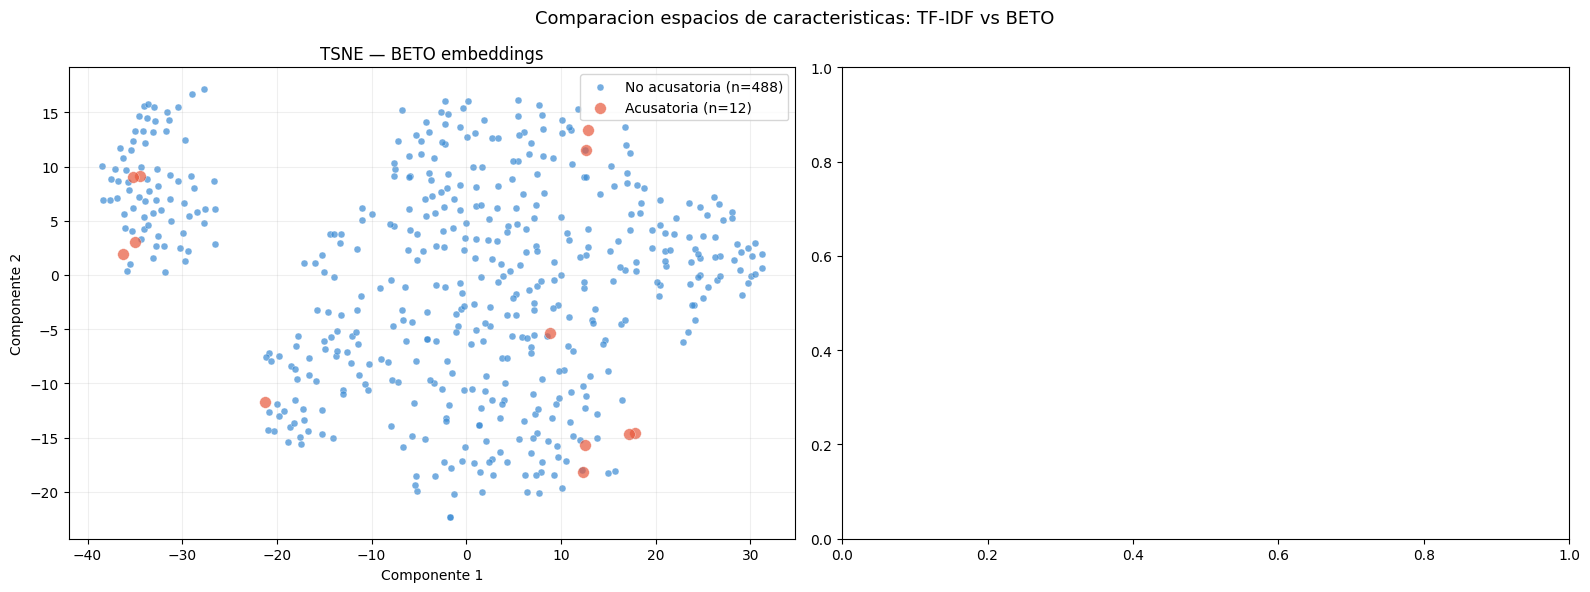

In [ ]:
N_SAMPLE = min(500, len(X_emb_train))
idx = np.random.RandomState(42).choice(len(X_emb_train), N_SAMPLE, replace=False)
X_beto_sample = X_emb_train[idx]
y_beto_sample = y_train[idx]

print('Ejecutando TSNE sobre embeddings BETO...')
tsne_beto = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne_beto = tsne_beto.fit_transform(X_beto_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tfidf_available = 'X_tsne' in globals() and 'y_sample' in globals()

plot_configs = []
if tfidf_available:
    plot_configs.append((axes[0], X_tsne, y_sample, 'TSNE — TF-IDF'))

plot_configs.append((axes[1] if tfidf_available else axes[0],
                     X_tsne_beto, y_beto_sample, 'TSNE — BETO embeddings'))

for ax, X_2d, y_2d, title in plot_configs:
    for label, color, name, size in [
        (0, '#3B8BD4', 'No acusatoria', 25),
        (1, '#E8593C', 'Acusatoria',    70)
    ]:
        mask = y_2d == label
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=color,
            label=f'{name} (n={mask.sum()})',
            alpha=0.7,
            s=size,
            edgecolors='white',
            linewidths=0.3
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)

plt.suptitle('Comparacion espacios de caracteristicas: TF-IDF vs BETO', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Conclusiones

El presente proyecto abordó la clasificación automática de preguntas acusatorias en procesos de contratación pública ecuatoriana, un problema de clasificación binaria de texto en español con severo desbalance de clases (97.1% no acusatorias / 2.9% acusatorias, ratio 33:1).

**Desbalance de clases y métricas:**
El desbalance fue el desafío central del proyecto. Se adoptó `class_weight="balanced"` en todos los modelos y F1-macro como métrica de optimización, descartando accuracy que daría 97% sin aprender nada útil. El EDA reveló que las preguntas acusatorias son significativamente más largas (477 vs 234 caracteres en promedio), lo que sugiere mayor argumentación — coherente con su naturaleza acusatoria.

**Optimización de hiperparámetros:**
La búsqueda bayesiana con Optuna (TPE sampler, 30 trials) sobre Repeated Stratified K-Fold CV (10 repeticiones × 10 folds) encontró eficientemente los mejores hiperparámetros. Para Regresión Logística: F1-macro CV = 0.7348 con C=2.05, penalty=L2, 10,000 features y unigramas. Para SVM lineal: F1-macro CV = 0.7312 con C=0.06, 20,000 features y bigramas. El hiperparámetro más influyente fue `penalty` (L1 vs L2) con ~45% de importancia relativa. Las curvas de aprendizaje muestran que ambos modelos convergen establemente y no presentan overfitting significativo — la brecha entre train y validación es pequeña y constante, indicando buena generalización dado el tamaño del dataset.

**Comparación estadística — Test de Wilcoxon:**
El test de Wilcoxon de rangos con signo sobre los scores pareados del CV arrojó W=1871, p=0.4776. Este resultado confirma que no existe diferencia estadísticamente significativa entre Regresión Logística y SVM lineal (p >= 0.05). La interpretación es directa: ambos son clasificadores lineales y en el espacio TF-IDF de alta dimensión (10,000-20,000 features) tienden a encontrar hiperplanos separadores equivalentes. Ninguno supera al otro de forma consistente a lo largo de los folds — en algunos gana LR, en otros SVM, sin patrón sistemático.

**Visualización TSNE — interpretación:**
La proyección TSNE en 2D revela por qué el problema es intrínsecamente difícil. En el espacio TF-IDF las preguntas acusatorias (clase positiva) están completamente dispersas y mezcladas con las no acusatorias, sin ningún agrupamiento geométrico visible. Esto indica que las preguntas acusatorias no tienen un vocabulario propio claramente diferenciable — pueden usar las mismas palabras que preguntas neutras, pero con un tono o estructura argumentativa diferente que TF-IDF no captura. En el espacio de embeddings BETO frozen aparece un agrupamiento parcial en la esquina inferior izquierda, donde varios puntos acusatorios se concentran. Esto confirma que BETO captura información semántica contextual ausente en TF-IDF, y justifica el uso de representaciones densas para este problema.

**Progresión de modelos y resultados finales:**
La estrategia experimental siguió una progresión coherente desde modelos simples hacia representaciones más ricas:

| Modelo | F1-macro | Precision acus. | Recall acus. | F1 acus. |
|---|---|---|---|---|
| TF-IDF + LR | 0.7136 | 0.35 | 0.62 | 0.45 |
| TF-IDF + SVM lineal | 0.7299 | 0.4 | 0.59 | 0.48 |
| Ensemble LR+SVM | 0.7244 | 0.48 | 0.45 | 0.46 |
| BETO frozen + LR | 0.7007 | 0.36 | 0.52 | 0.42 |
| BETO + SVM RBF | 0.7300 | 0.40 | 0.59 | 0.48 |
| **BETO fine-tuned** | **0.7386** | **0.69** | **0.38** | **0.49** |

TF-IDF con clasificadores lineales establece un baseline sólido. El Wilcoxon confirma que agregar complejidad lineal (SVM) no mejora significativamente sobre LR. BETO frozen con LR baja respecto a TF-IDF porque los embeddings genéricos entrenados en Wikipedia no capturan el lenguaje legal específico de contratación pública. BETO con SVM RBF recupera el rendimiento porque el kernel gaussiano captura la estructura no lineal visible en el TSNE. El Ensemble LR+SVM mejora la precision (0.48) a costa de recall, siendo útil cuando se priorizan alertas confiables sobre cobertura total.

**Fine-tuning de BETO — interpretación:**
El entrenamiento con 4 epochs, learning rate 2e-5 y warmup del 10% mostró una progresión clara y esperada. La loss cayó de 0.8805 a 0.0410 mientras el F1-macro subió de 0.4927 a un máximo de 0.7439 en epoch 3, bajando levemente a 0.7386 en epoch 4. Esta caída en epoch 4 con loss casi en cero (0.0410) es una señal inequívoca de inicio de overfitting — el modelo memoriza el conjunto de entrenamiento. Con solo 118 muestras positivas en train, 4 epochs es el límite razonable. El fine-tuned logra la mayor precision de todos los modelos (0.69), lo que significa que cuando predice una pregunta como acusatoria tiene alta confianza. El trade-off es un recall menor (0.38) — es conservador, pero sus alertas son más confiables. El ajuste del umbral de decisión de 0.5 a 0.86 sobre LR mejoró el F1 de acusatoria de 0.45 a 0.5714, demostrando que la calibración del umbral es una palanca efectiva e inmediata sin necesidad de reentrenar.

**Trabajo futuro:**
Las mejoras más prometedoras en orden de impacto esperado son: data augmentation sobre las 147 muestras acusatorias mediante back-translation para enriquecer el conjunto positivo antes del fine-tuning; validación con 10 repeticiones × 10 folds para un test de Wilcoxon más potente estadísticamente; early stopping en el fine-tuning para detener en epoch 3 donde el F1 es máximo; y exploración de modelos especializados en lenguaje legal en español aplicados al corpus específico de contratación pública ecuatoriana.


---
## 11. Referencias

**Artículos científicos:**

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: A Next-generation Hyperparameter Optimization Framework. *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining*, 2623-2631.

Cañete, J., Chaperon, G., Fuentes, R., & Pérez, J. (2020). Spanish Pre-Trained BERT Model and Evaluation Data. *ICLR 2020 Workshop on Practical ML for Developing Countries*.

Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL-HLT 2019*, 4171-4186.

Wilcoxon, F. (1945). Individual Comparisons by Ranking Methods. *Biometrics Bulletin*, 1(6), 80-83.

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321-357.

Van der Maaten, L., & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9, 2579-2605.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273-297.

**Herramientas y código fuente:**

Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., ... & Rush, A. M. (2020). HuggingFace Transformers: State-of-the-art Natural Language Processing. *EMNLP 2020*. https://github.com/huggingface/transformers

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. *NeurIPS 2019*. https://pytorch.org

BETO — Spanish BERT. Universidad de Chile. https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased

Optuna: A hyperparameter optimization framework. https://optuna.readthedocs.io

Scikit-learn: Machine Learning in Python. https://scikit-learn.org

imbalanced-learn: A Python toolbox to tackle the curse of imbalanced datasets. https://imbalanced-learn.org
